#  Model Evaluation Notebook

**Description**

This notebook is used for model performance evaluation by calculating these metrics including IoU and Dice coefficient (F1-score) and model prediction visualization on the whole area.

**Input folder(s)/file(s)**

- Folder path to test image tiles (example: ../data/processed/tiles/test)
- Public Urban Green Spaces (PUGS) ground truth (geojson file) (example: dresden_pugs_gt.geojson)
- Public Urban Green Spaces (PUGS) ground truth (raster) (example: dresden_pugs_gt.geotiff)
- The best model checkpoint file (example: epoch=47-val_loss=0.18.ckpt)
- Metrics file (CSV file) (metrics.csv)
- Sentinel-2 image stack with PUGS OSM binary mask and SDT (stacked_sentinel2_dresden.geotiff)

**Output folder(s)/file(s)**

- Output folder for prediction result visualization (example: ../reports/visualization/v1)
- Loss graph over Epochs (example: loss_graph_v1.png)
- Whole area prediction (example: prediction_sat_osm_v1.geotiff)

**Requirements/Dependencies**

This notebook requires user to run the following notebooks first:
- 1_data_acquisition_osm.ipynb
- 1_data_acquisition_satellite_image.ipynb
- 2_data_processing_osm.ipynb
- 3_data_processing_satellite_image.ipynb
- 4_ground_truth_creation.ipynb
- 5_model_training.ipynb

In case all the input data required in this notebook are available, user can directly run this notebook without running the notebooks in the list.

# Import libraries

In [148]:
import os
import sys

# Add the root directory to Python path so that we can import the modules
root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(root_dir)

In [149]:
import torchgeo
import torch
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.callbacks import EarlyStopping
from lightning.pytorch.loggers import CSVLogger
from tqdm import tqdm
from torch.utils.data import DataLoader
from torchgeo.datasets.utils import stack_samples
from lightning.pytorch import Trainer
from pugs_detection.modeling.segmentation_task import (
    CustomSegmentationTask
)
from pugs_detection.modeling.evaluation import (
    generate_confusion_matrix
)
from pugs_detection.plots import (
    visualize_area,
    visualize_from_torchgeo_dataloader,
    visualize_predictions,
    plot_loss_graph
)
from pugs_detection.dataset import (
    PredictedImageDataset,
    create_dataset_split
)
from pugs_detection.utils import (
    set_all_seeds
)
from pugs_detection.modeling.predict import (
    predict_whole_area
)

In [150]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="You will likely lose important projection information when converting to a PROJ string from another format.*",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message="Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired.*",
    category=UserWarning,
)

# Set seed for reproducibility

In [151]:
set_all_seeds(42)

Seed set to 42


# Set variables

In [152]:
test_image_path = "../data/processed/tiles/test"
label_path = "../data/processed/ground truth/dresden_pugs_gt.geojson"
band_list_predict = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14]
num_channels = len(band_list_predict)

batch_size = 16
epochs = 50

# Path to your checkpoint file
version = 8
checkpoint_path = f"../models/checkpoints/version_{version}/checkpoints/epoch=27-val_loss=0.00.ckpt"

# Logger path
logger_path = "../models"
sub_folder_name = "test_result"

metrics_path = f"../models/checkpoints/version_{version}/metrics.csv"
loss_graph_path = f"../reports/figures/loss graph/loss_graph_v{version}.png"

image_path_whole_area = "../data/processed/sentinel-2/stacked_sentinel2_dresden.geotiff"
prediction_image_path = f"../reports/prediction_results_track/whole_area_prediction/prediction_sat_sdt_v{version}.geotiff"

ground_truth_path = "../data/processed/ground truth/dresden_pugs_gt.geotiff"

output_dir = f"../reports/visualization/v{version}"

# Create Test dataloader

In [153]:
test_dataset = create_dataset_split(
    test_image_path, label_path, 32633, band_list_predict, "test", None
)

Seed set to 42


Using all 36 patches for test set


In [154]:
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, collate_fn=stack_samples, num_workers=1
)

In [155]:
len(test_loader)

3

Seed set to 42


Sample 0:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.39


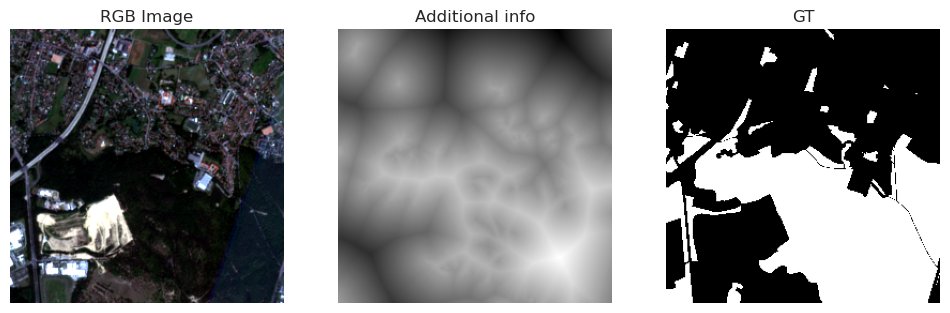

Sample 1:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.49


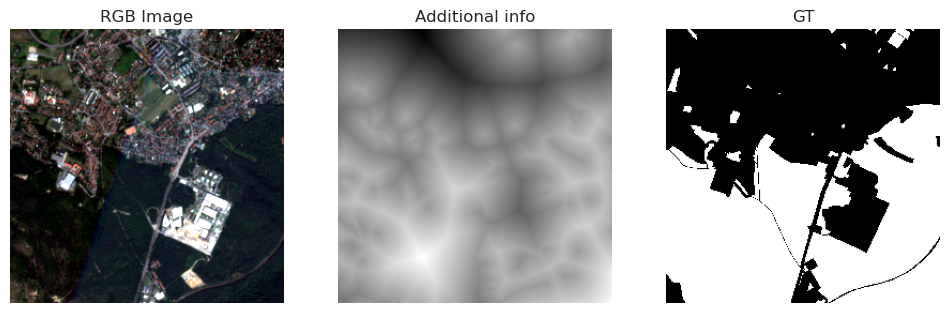

Sample 2:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.71


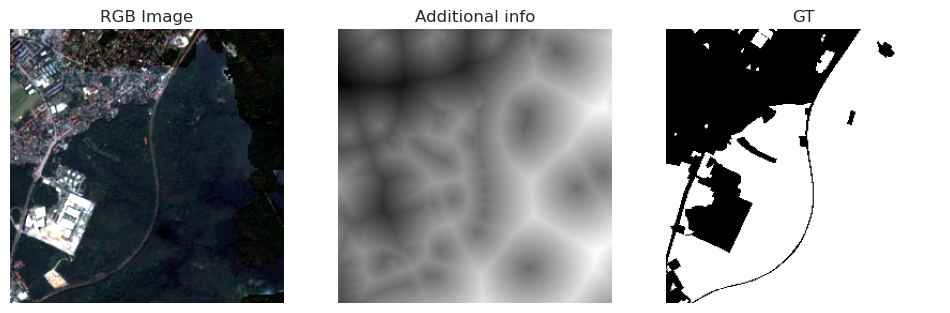

In [156]:
if num_channels > 13:
    visualize_from_torchgeo_dataloader(test_loader, 3, 'additional', [13])
else:
    visualize_from_torchgeo_dataloader(test_loader, 3, "original")

# Load model from checkpoint

In [157]:
# Direct loading with the correct channel count
model = CustomSegmentationTask.load_from_checkpoint(
    checkpoint_path,
    in_channels=num_channels,  # Match what's in the checkpoint
)

# Evaluate the model

In [158]:
checkpoint_callback = ModelCheckpoint(
    filename="{epoch:02d}-{val_loss:.2f}",
    monitor="val_loss",
    save_top_k=2,  # Save chckpoint with the best validation loss
    # every_n_epochs=5  # Save checkpoint every n epochs
)

In [159]:
early_stopping = EarlyStopping(monitor="val_loss", patience=10)

In [160]:
logger = CSVLogger(logger_path, name=sub_folder_name)

In [161]:
trainer = Trainer(
    max_epochs=epochs,
    deterministic=True,
    accelerator="cpu",
    log_every_n_steps=1,
    callbacks=[checkpoint_callback, early_stopping],
    logger=logger,
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


## Viz prediction

In [162]:
trainer.test(model=model, dataloaders=test_loader, ckpt_path=checkpoint_path)

Restoring states from the checkpoint path at ../models/checkpoints/version_8/checkpoints/epoch=27-val_loss=0.00.ckpt
/root/miniforge3/envs/pugs-detection-new/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:362: The dirpath has changed from '../models/checkpoints/version_8/checkpoints' to '../models/test_result/version_8/checkpoints', therefore `best_model_score`, `kth_best_model_path`, `kth_value`, `last_model_path` and `best_k_models` won't be reloaded. Only `best_model_path` will be reloaded.
Loaded model weights from the checkpoint at ../models/checkpoints/version_8/checkpoints/epoch=27-val_loss=0.00.ckpt
/root/miniforge3/envs/pugs-detection-new/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   test_BinaryAccuracy       0.95313560962677
 test_BinaryJaccardIndex    0.7259910106658936
        test_loss          6.102559382270556e-07
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_BinaryAccuracy': 0.95313560962677,
  'test_BinaryJaccardIndex': 0.7259910106658936,
  'test_loss': 6.102559382270556e-07}]

Prediction shape: torch.Size([16, 1, 256, 256])
Mask shape: torch.Size([16, 256, 256])
Sample 0 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 1.0
Sample 1 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 1.0
Sample 2 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 1.0
Sample 3 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.7983424067497253


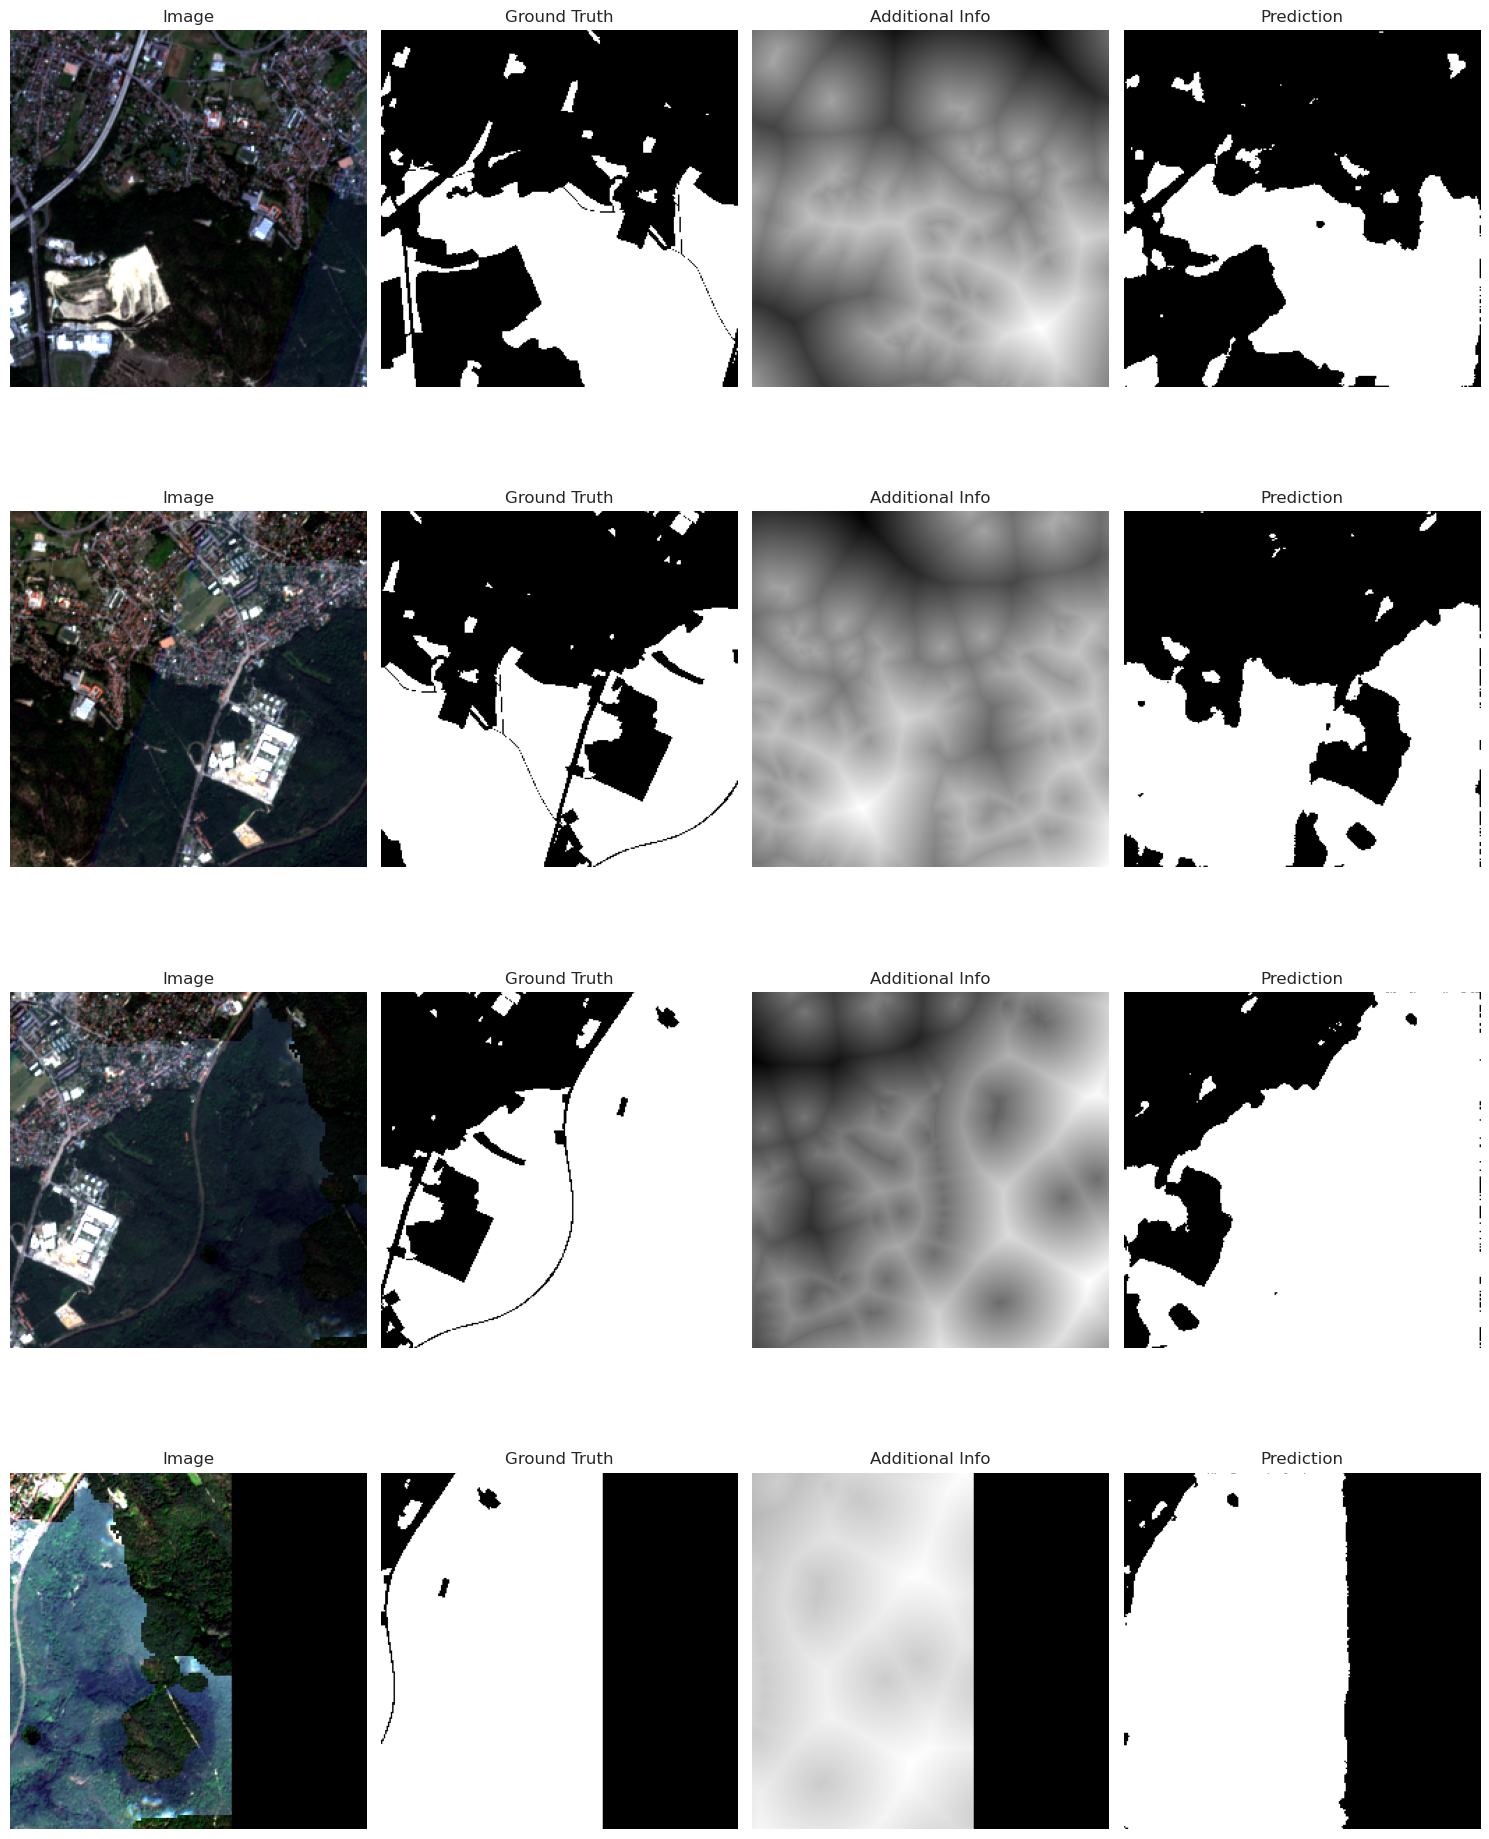

Prediction shape: torch.Size([16, 1, 256, 256])
Mask shape: torch.Size([16, 256, 256])
Sample 0 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 1.0
Sample 1 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 1.0
Sample 2 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.9967949390411377
Sample 3 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.9246196150779724


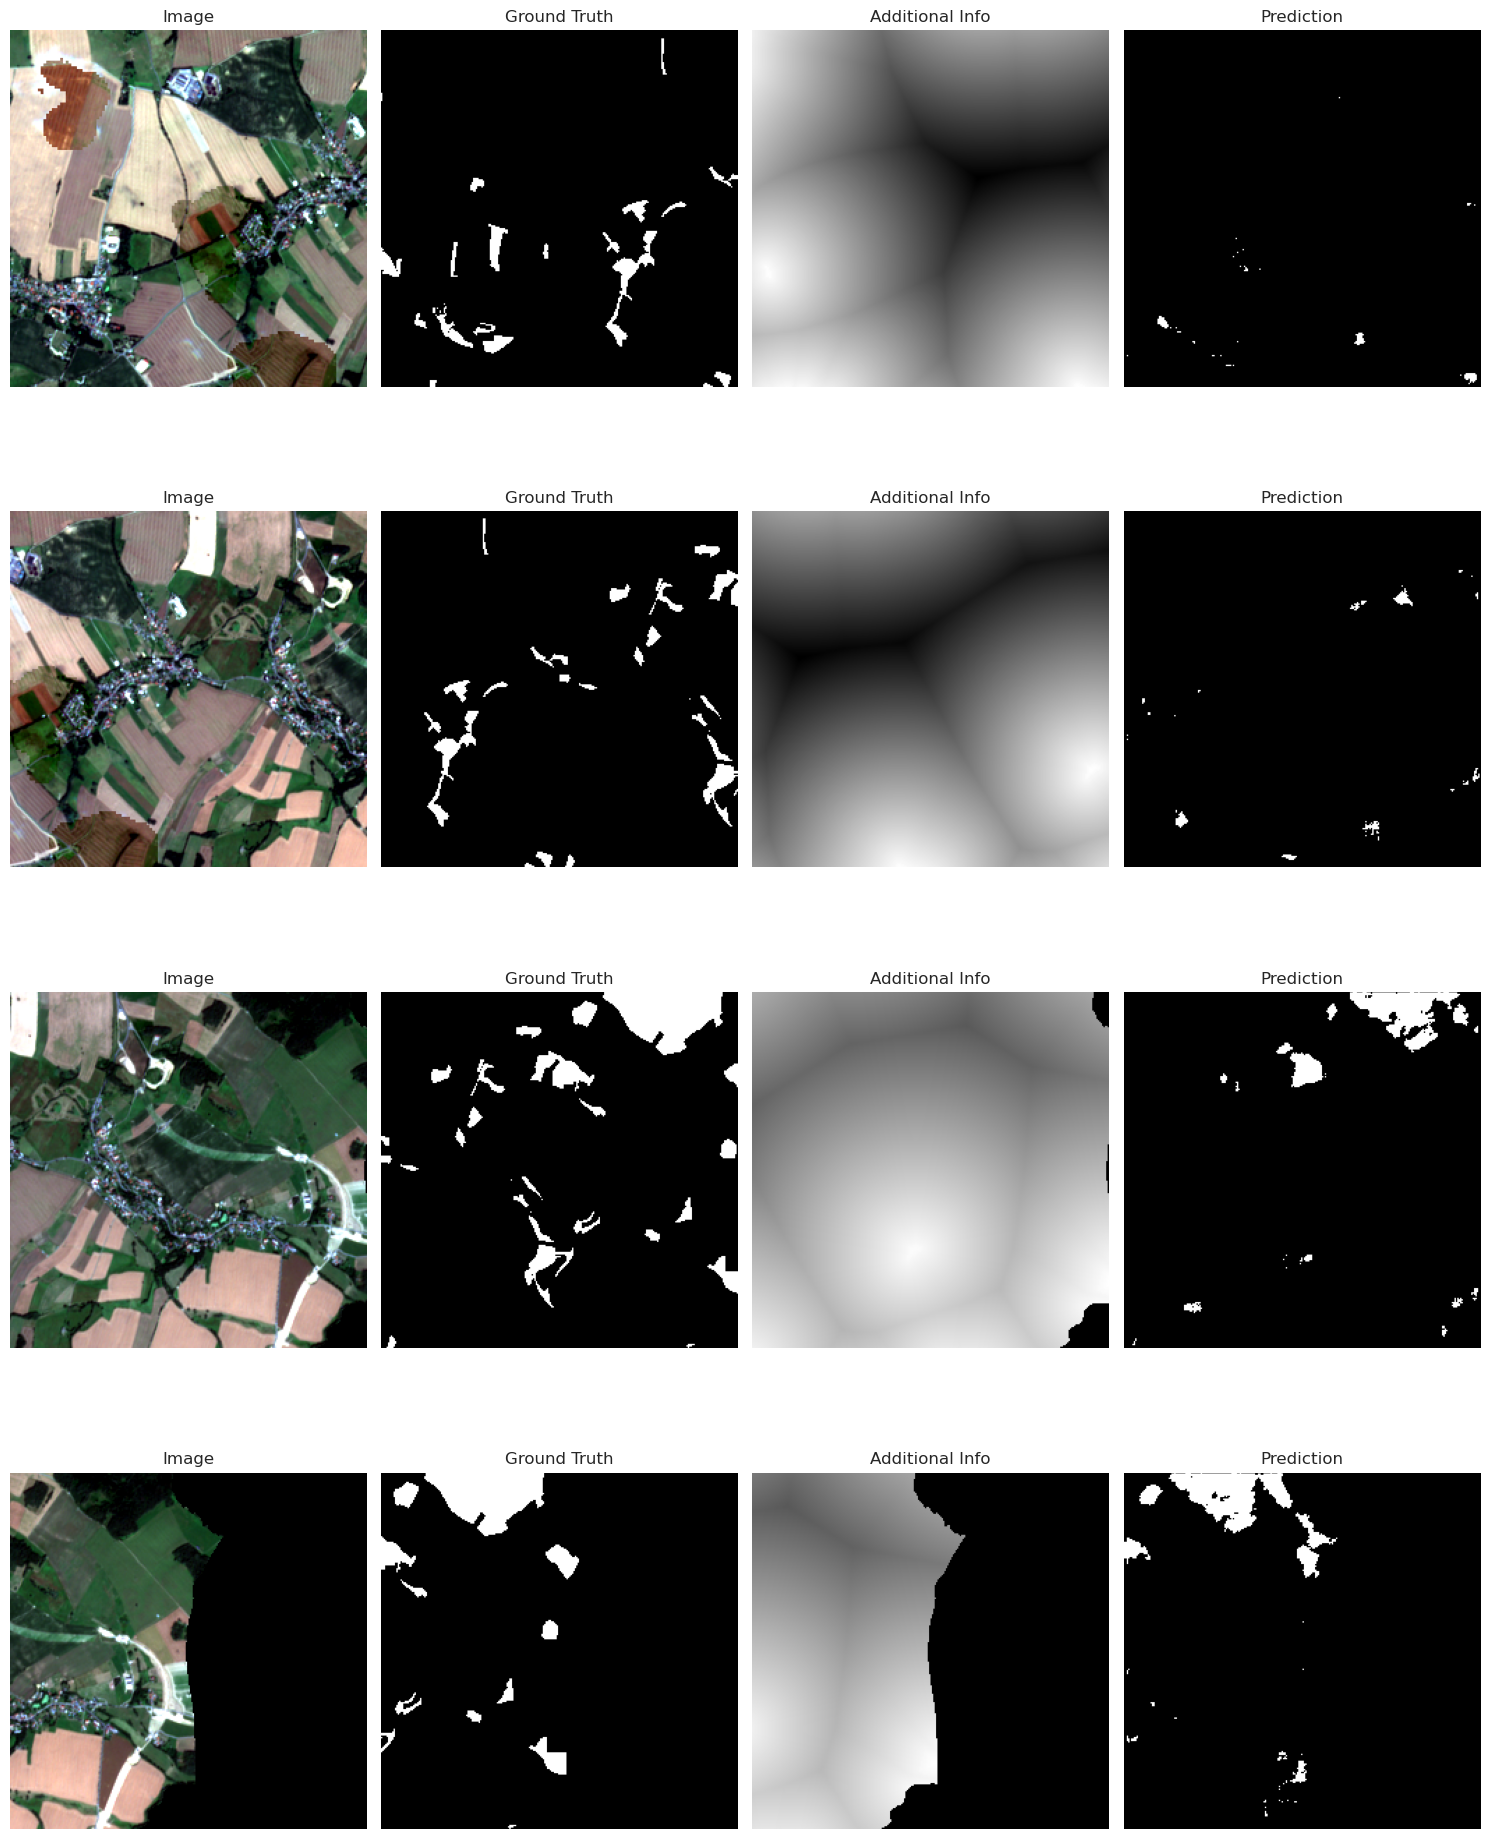

Prediction shape: torch.Size([4, 1, 256, 256])
Mask shape: torch.Size([4, 256, 256])
Sample 0 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.8341105580329895
Sample 1 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.881877064704895
Sample 2 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.870665431022644
Sample 3 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.7889150977134705


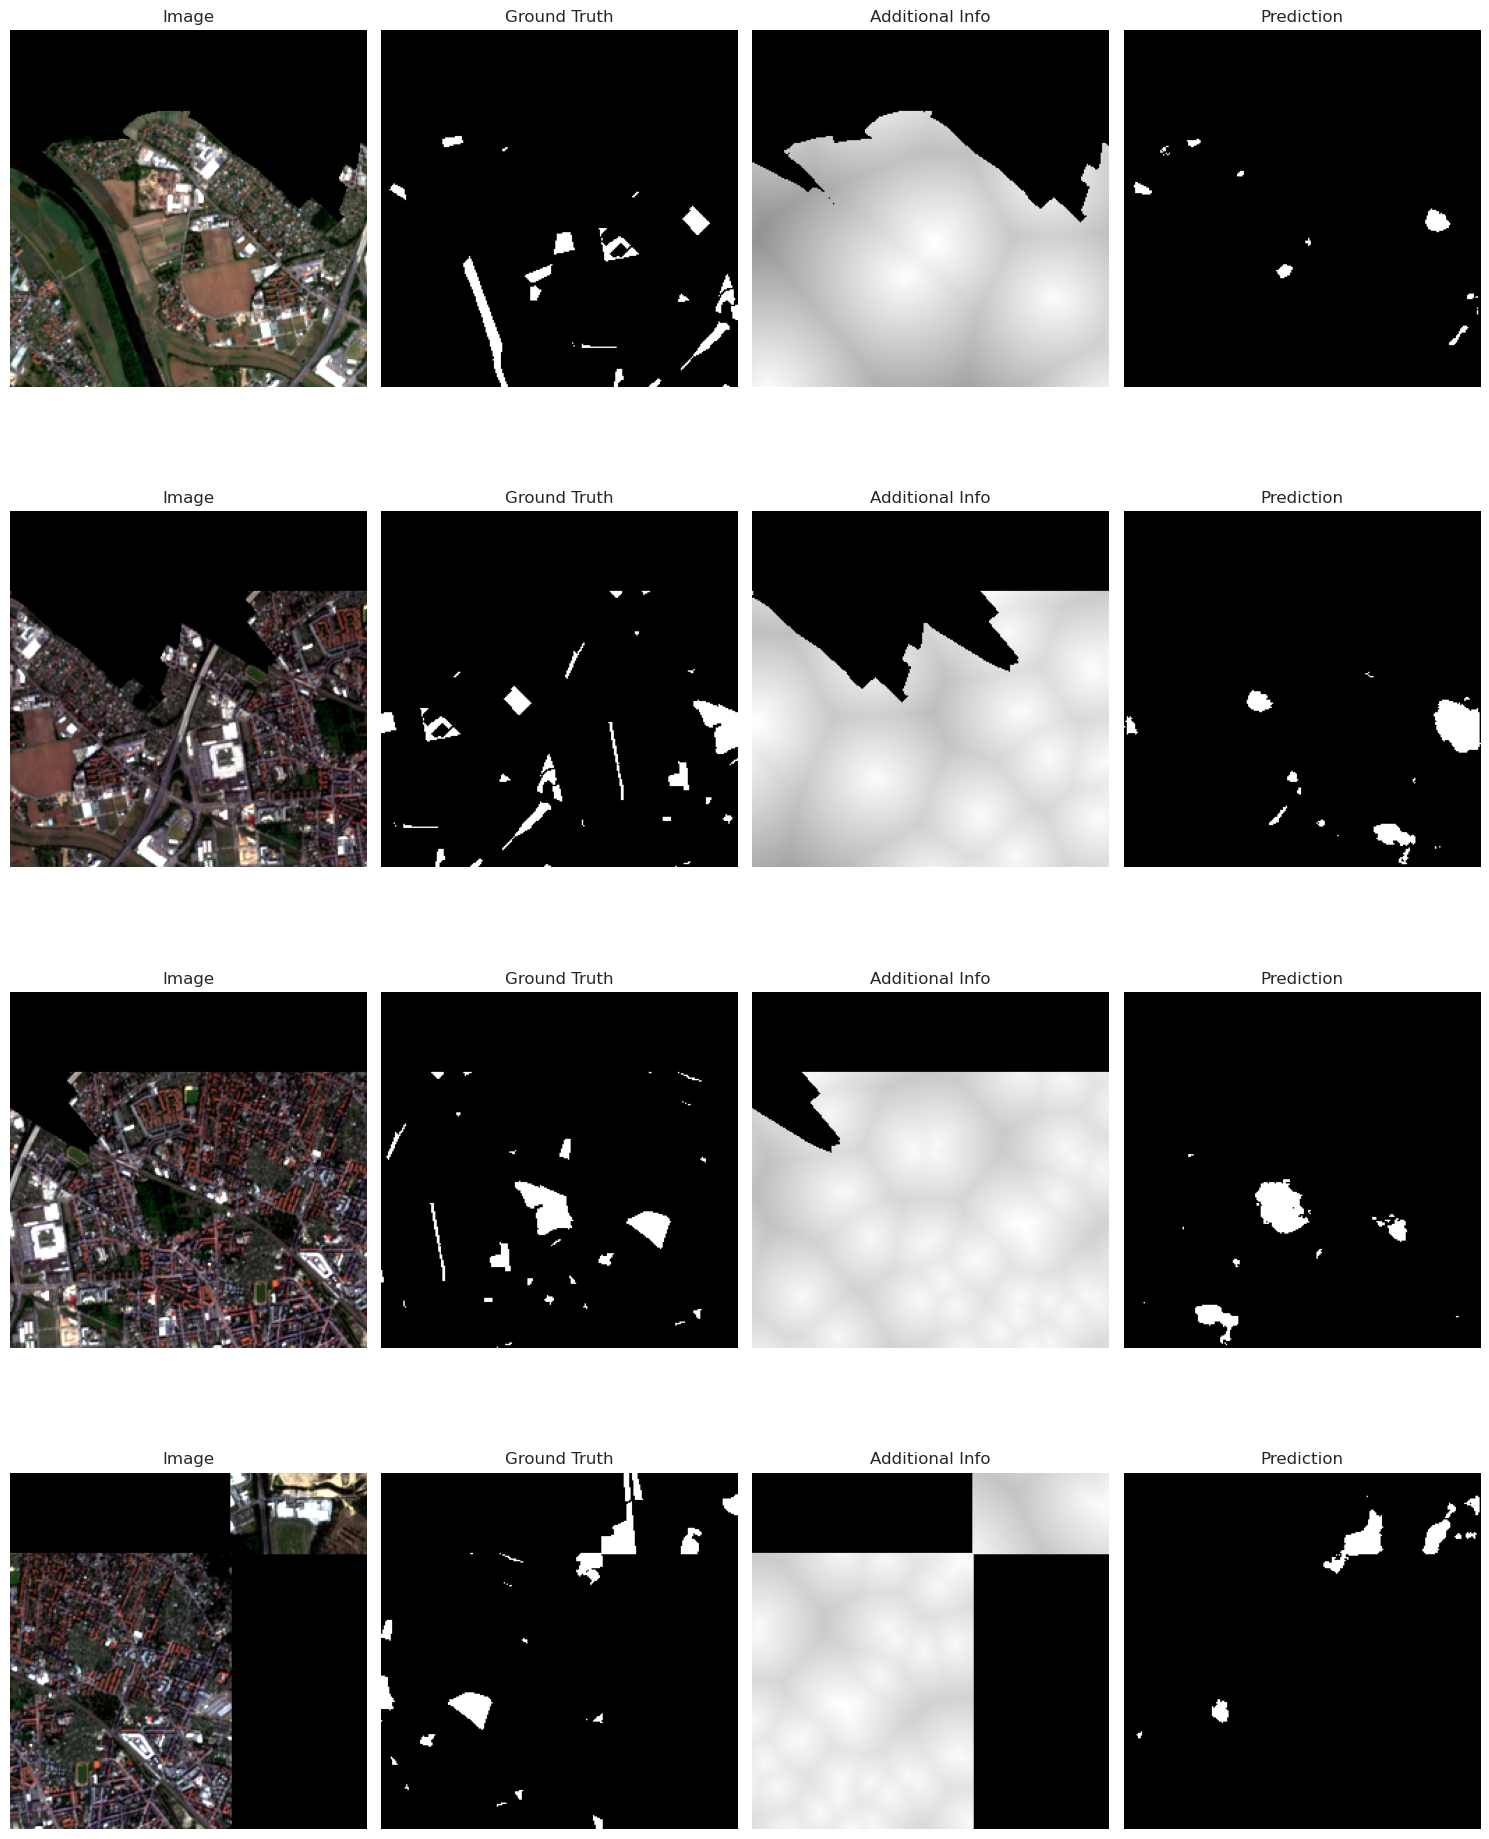

In [163]:
if num_channels > 13:
    visualize_predictions(model, test_loader, mode='additional', replace_band_pos=[13], output_dir=output_dir)
else:
    visualize_predictions(model, test_loader, mode="original", output_dir=output_dir)

## Confusion matrix

In [164]:
cm = generate_confusion_matrix(model, test_loader)
print("True Negative:", cm[0, 0])
print("False Positive:", cm[0, 1])
print("False Negative:", cm[1, 0])
print("True Positive:", cm[1, 1])

True Negative: 1955780
False Positive: 39398
False Negative: 71169
True Positive: 292949


In [165]:
precision = cm[1, 1] / (cm[1, 1] + cm[0, 1])
recall = cm[1, 1] / (cm[1, 1] + cm[1, 0])
f1 = 2 * precision * recall / (precision + recall)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Accuracy: {np.sum(np.diag(cm)) / np.sum(cm):.4f}")
print(f"IoU: {cm[1, 1] / (cm[1, 1] + cm[0, 1] + cm[1, 0]):.4f}")

Precision: 0.8815
Recall: 0.8045
F1 Score: 0.8412
Accuracy: 0.9531
IoU: 0.7260


# Plot train loss and val loss

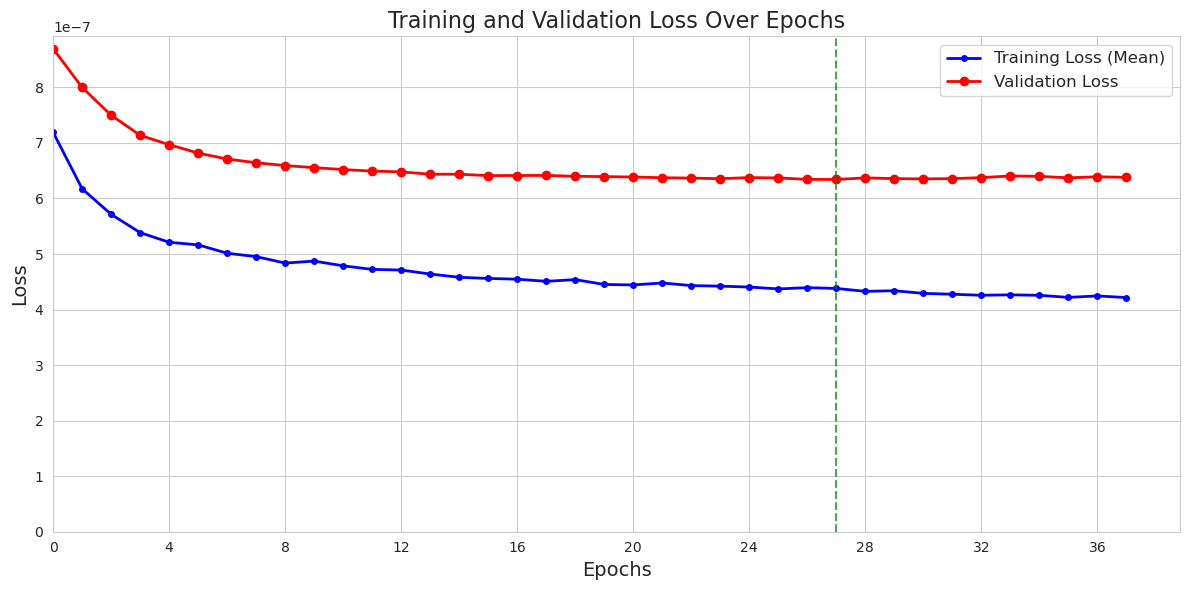

Best model at epoch 27:
  Val Loss: 0.0000
  Val Jaccard: 0.8131


In [166]:
plot_loss_graph(metrics_path, loss_graph_path)

# Predict whole area

In [167]:
# Use custom collate function to maintain window_ifo as list of tuples
# so we can easily extract the window coordinates
def custom_collate_fn(batch):
    """Keep window coordinates as a list of tuples instead of tensors"""
    images = torch.stack([torch.from_numpy(item["image"]) for item in batch])
    window_infos = [item["window_info"] for item in batch]

    return {"image": images, "window_info": window_infos}

In [168]:
inference_dataset = PredictedImageDataset(image_path_whole_area, patch_size=256, stride=256, band_list_predict=band_list_predict)
inference_loader = DataLoader(
    inference_dataset,
    batch_size=4,
    num_workers=4,
    collate_fn=custom_collate_fn,  # Use custom collate function
)

In [169]:
prediction_map = predict_whole_area(model, inference_dataset, inference_loader)

100%|██████████| 25/25 [00:09<00:00,  2.62it/s]


In [170]:
# Save the prediction
with rasterio.open(
    prediction_image_path,
    "w",
    driver="GTiff",
    height=inference_dataset.height,
    width=inference_dataset.width,
    count=1,
    dtype=rasterio.float32,
    crs=inference_dataset.crs,
    transform=inference_dataset.transform,
) as dst:
    dst.write(prediction_map[np.newaxis, :, :])

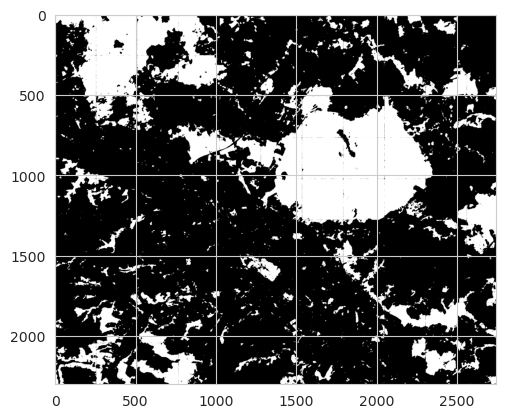

In [171]:
open_image = rasterio.open(prediction_image_path)
image = open_image.read(1)
plt.imshow(image, cmap="gray")
open_image.close()

# Save the visualization of prediction and ground truth

In [172]:
viz_coords = [
    (256, 640), (512, 896), (512, 1152), (1920, 2000), (640,0), 
    (768, 1152), (896, 1024), (896, 1152), (896, 1280), (1024, 1024), 
    (1024, 1280), (1024, 1536), (1152, 1408), (1408, 1280), (1536, 1536)
]

In [173]:
for x, y in tqdm(viz_coords, desc="Generating visualizations", unit="image"):
    try:
        fig = visualize_area(
            original_image_path=image_path_whole_area,
            prediction_path=prediction_image_path,
            ground_truth_path=ground_truth_path,
            x_coord=x,
            y_coord=y,
            window_size=256
        )
        
        if output_dir:
            # Save to file
            fig_path = os.path.join(output_dir, f"region_{x}_{y}.png")
            fig.savefig(fig_path, bbox_inches='tight', dpi=300)
            plt.close(fig)        
    except Exception as e:
        print(f"Error visualizing window at ({x},{y}): {e}")

print()
print("Complete saving the files")

Generating visualizations: 100%|██████████| 15/15 [00:06<00:00,  2.22image/s]


Complete saving the files


In [174]:
# Usage example with output directory
# visualize_whole_image(
#     original_image_path=image_path,
#     prediction_path=file_output_path,
#     ground_truth_path='../data/processed/ground truth/dresden_pugs_gt.geotiff',
#     window_size=256,
#     stride=128,  # Larger stride to sample fewer areas
#     output_dir='../reports/visualization/region_samples'
# )